In [2]:
import line_data as ln
import essentials as es
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as cns
import random as random
import json

#### The list of emission lines now present in the spectra

In [ ]:
ln.line_list()

,Line,Wavelength,broad/narrow,amplitude
1,Hgamma,4340.471,bn,0.2
2,HeII,4685.71,b,0.1
3,Hbeta,4861.333,bn,0.3
4,OIII_1,4958.911,n,0.5
5,OIII_2,5006.843,n,1.0
6,NII_1,6548.05,n,0.4
7,Halpha,6562.819,bn,0.8
8,NII_2,6583.46,n,0.4
9,SII_1,6716.44,n,0.2
10,SII_2,6730.81,n,0.2


#### The basic spectral model:

F = AGN_spectrum + galaxy_template + emission lines + gaussian_noise

1. AGN_spectrum: $f_{\lambda} = A \lambda^{-\alpha}$. $\alpha$ is seclected randomly from the range (0.5, 3.0)

2. Galaxy templates are taken from from Mannucci et al. (2001), MNRAS, 326, 745. The templates are either E0, S0, Sa, Sb or Sc and are selected randomly with same probability during simulation to increase the variety of the training and test datasets.  

3. Emission lines broad/narrow modeled using Gaussian profiles. The narrow line FWHM is randomly selected from the range (200 km/s, 400 km/s). The broad line FWHM is randomly selected from the range (1000 km/s, 5000 km/s).

4. Gaussian noise

The unit of total flux is arbitrary here.

#### Simulate the train and test datasets

In [ ]:
def spectral_data(type):
    """
    type: Type-1, Type-1.9 or Type-2
    Returns a tuple of (wavelengths, fluxes) for the given type.
    """
    lamda_min = random.randint( 3500, 4500 )
    lamda_max = random.randint( 6700, 7500 )
    
    del_lamda = random.randint(1,10) + random.choice([0.0, 0.25, 0.5])

    z = np.random.random() ## redshift
    x = np.arange(lamda_min, lamda_max, del_lamda)
    y = es.total_spectrum(x, type)
    return (x*(1+z), y)

#### Paths to save the training datasets

In [ ]:
path_type1 = 'simulated_data/training/type-1/'
path_type1pt9 = 'simulated_data/training/type-1.9/'
path_type2 = 'simulated_data/training/type-2/'

N = 5000 # Number of training sets to generate

#### Write the files

In [4]:
for i in range(N):
    x,y = spectral_data("Type-1")
    A = {"x":x.tolist(),
         "y":y.tolist(),
         "t":0}
    #with open(path_type1+'spec'+str(i)+'.json', 'w') as fp:
    #    json.dump(A, fp)

In [5]:
for i in range(N):
    x,y = spectral_data("Type-1.9")
    A = {"x":x.tolist(),
         "y":y.tolist(),
         "t":1.0}
    #with open(path_type1pt9+'spec'+str(i)+'.json', 'w') as fp:
    #    json.dump(A, fp)

In [6]:
for i in range(N):
    x,y = spectral_data("Type-2")
    A = {"x":x.tolist(),
         "y":y.tolist(),
         "t":2.0}
    #with open(path_type2+'spec'+str(i)+'.json', 'w') as fp:
    #    json.dump(A, fp)

#### Some testing files for the trained model 

In [ ]:
path_type1 = 'simulated_data/test_classify_spectrum/'
path_type1pt9 = 'simulated_data/test_classify_spectrum/'
path_type2 = 'simulated_data/test_classify_spectrum/'

Text(0, 0.5, 'Flux (arbitrary units)')

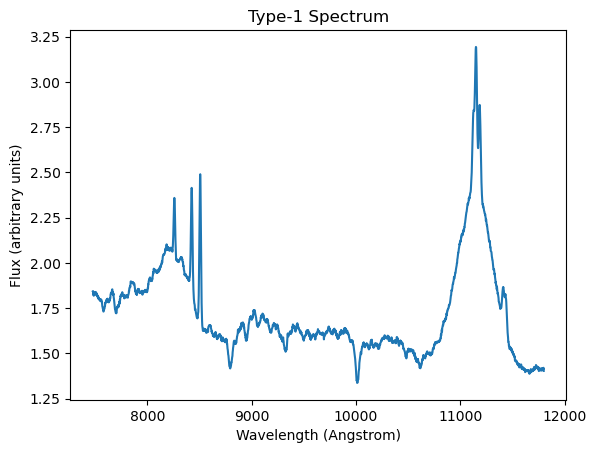

In [8]:
x,y = spectral_data("Type-1")

DataOut = np.column_stack((x,y))
#np.savetxt(path_type1+"spec1.txt",DataOut)

plt.title("Type-1 Spectrum")
plt.plot(x,y)
plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux (arbitrary units)")

Text(0, 0.5, 'Flux (arbitrary units)')

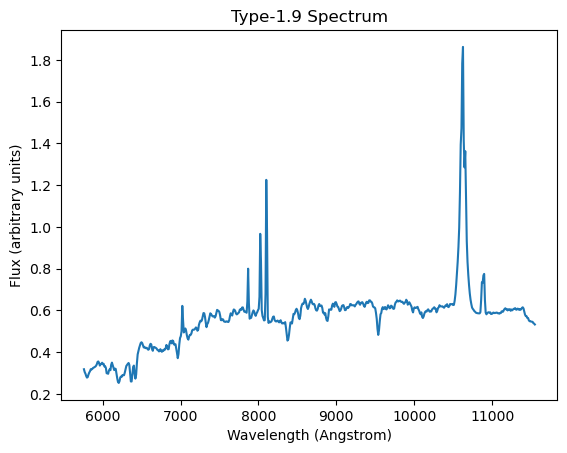

In [9]:
x,y = spectral_data("Type-1.9")

DataOut = np.column_stack((x,y))
#np.savetxt(path_type1+"spec2.txt",DataOut)

plt.title("Type-1.9 Spectrum")
plt.plot(x,y)
plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux (arbitrary units)")

Text(0, 0.5, 'Flux (arbitrary units)')

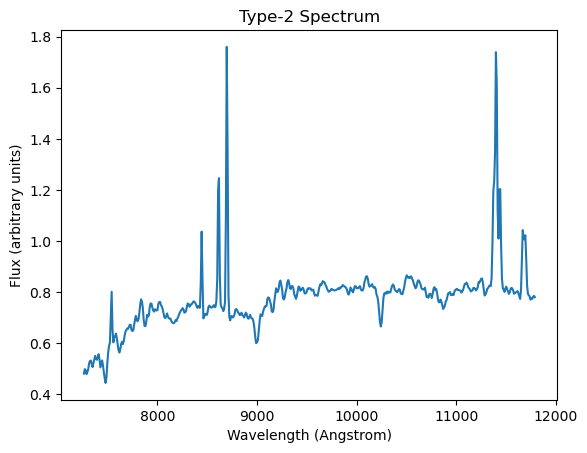

In [10]:
x,y = spectral_data("Type-2")

DataOut = np.column_stack((x,y))
#np.savetxt(path_type1+"spec3.txt",DataOut)

plt.title("Type-2 Spectrum")
plt.plot(x,y)
plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux (arbitrary units)")
